# Assignment 6
### Do Question 6, and three more questions of your choice.

### 1. Set review:

- Operations on sets (hints: sketch venn-type diagrams, and showing $A=B$ is the same as $A \subseteq B$ and $B \subseteq A$):
    - $ (A \backslash B) \cup (A \cap B) = A $
    - $ A \cup ( B \cap C) = (A \cup B) \cap (A \cup C)$
    - $ A \backslash (B \cup C) = A\backslash B \cap A \backslash C $ and $A \backslash (B \cap C) = A \backslash B \cup A \backslash C$

- Plot the following sets: 
    - $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$ 
    - $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$
    - $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$
    - $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$

- The power set of $A$ is the set of all subsets of $A$, denoted $\mathcal{P}(A)$. What is the power set of $\{ 1, 2, 3 \}$? (Hint: The empty set is a subset of every set; the whole set is a subset of itself.)

#### 1. a. Operations on Sets

In [ ]:
!pip install matplotlib_venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib_venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=98293fba87eec6c02b963af2563a0e30644dfb736f9d3b326429ffb60d5ffda8
  Stored in directory: /Users/khansaamaa/Library/Caches/pip/wheels/d1/5f/e6/771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib_venn


In [ ]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
from collections import Counter
from scipy.stats import logistic, expon
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

In [11]:
# Example sets
A = set([1, 2, 3, 4, 5, 6])
B = set([4, 6, 8])
C = set([5, 7, 9])


In [26]:
# Helper function to shade only the desired region
def highlight_venn2(set1, set2, label1, label2, highlight_regions, title):
    plt.figure(figsize=(6, 4))
    v = venn2([set1, set2], set_labels=(label1, label2))
    for region in ['10', '01', '11']:
        if region in highlight_regions:
            if v.get_label_by_id(region): v.get_label_by_id(region).set_fontweight('bold')
            if v.get_patch_by_id(region): v.get_patch_by_id(region).set_color('skyblue')
        else:
            if v.get_patch_by_id(region): v.get_patch_by_id(region).set_color('lightgrey')
    plt.title(title)
    plt.show()

def highlight_venn3(set1, set2, set3, label1, label2, label3, highlight_regions, title):
    plt.figure(figsize=(6, 4))
    v = venn3([set1, set2, set3], set_labels=(label1, label2, label3))
    for region in ['100', '010', '001', '110', '101', '011', '111']:
        if region in highlight_regions:
            if v.get_label_by_id(region): v.get_label_by_id(region).set_fontweight('bold')
            if v.get_patch_by_id(region): v.get_patch_by_id(region).set_color('skyblue')
        else:
            if v.get_patch_by_id(region): v.get_patch_by_id(region).set_color('lightgrey')
    plt.title(title)
    plt.show()

```

Operation	            Result	                    Explanation
A ∩ B	             {4, 6}	                Elements common to A and B
A ∩ C	             {5}	                Elements common to A and C
B ∩ C	             {}	                    No overlap between B and C
A ∪ B	             {1,2,3,4,5,6,8}	    All elements from A and B
A ∪ C	             {1,2,3,4,5,6,7,9}	    All elements from A and C
B ∪ C	             {4,5,6,7,8,9}	        All elements from B and C
A \ B	             {1,2,3,5}	            Elements in A not in B
A \ C	             {1,2,3,4,6}	        Elements in A not in C
A \ (B ∪ C)	         {1,2,3}	            Remove all elements in B or C from A
A \ (B ∩ C)	         {1,2,3,4,5,6}	        Since B ∩ C is empty, this equals A
(A \ B) ∪ (A ∩ B)	 {1,2,3,4,5,6}	        Difference plus intersection reconstructs A
(A \ B) ∩ (A \ C)	 {1,2,3}	            Elements in A not in B and not in C
(A \ B) ∪ (A \ C)	 {1,2,3,4,5,6}	        Union of differences equals A minus (B ∩ C)

```

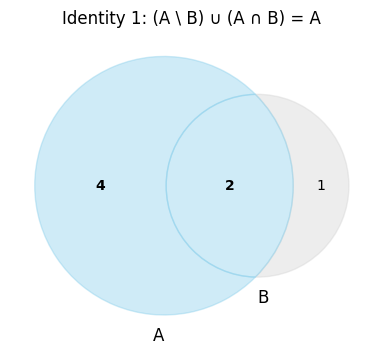

In [27]:
#1 (𝐴∖𝐵)∪(𝐴∩𝐵)=𝐴

highlight_venn2(A, B, "A", "B", highlight_regions=['10', '11'], title="Identity 1: (A \\ B) ∪ (A ∩ B) = A")

# The shaded area represents (A \ B) ∪ (A ∩ B), which is equal to A.

- (𝐴∖𝐵) ∪ (𝐴∩𝐵) = 𝐴

 → {1,2,3,5} ∪ {4,6} = {1,2,3,4,5,6}

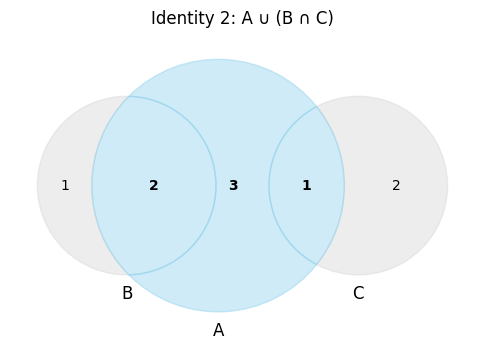

In [33]:
# 2 𝐴∪(𝐵∩𝐶)=(𝐴∪𝐵)∩(𝐴∪𝐶)

highlight_venn3(A, B, C, "A", "B", "C", highlight_regions=['100', '110', '101', '111', '011'], title="Identity 2: A ∪ (B ∩ C)")

# The shaded area represents A ∪ (B ∩ C), which is equal to (A ∪ B) ∩ (A ∪ C).

- 𝐴 ∪ (𝐵∩𝐶) = (𝐴∪𝐵) ∩ (𝐴∪C)
 
→ LHS: A ∪ ∅ = A 

→ RHS: {1,2,3,4,5,6,8} ∩ {1,2,3,4,5,6,7,9} = {1,2,3,4,5,6}

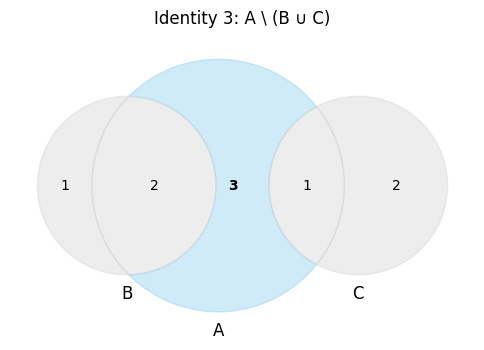

In [29]:
#3 𝐴∖(𝐵∪𝐶)=(𝐴∖𝐵)∩(𝐴∖𝐶)

highlight_venn3(A, B, C, "A", "B", "C", highlight_regions=['100'], title="Identity 3: A \\ (B ∪ C)")

# The shaded area represents A \ (B ∪ C), which is equal to (A \ B) ∩ (A \ C).


- 𝐴∖(𝐵∪𝐶) = (𝐴∖𝐵) ∩ (𝐴∖𝐶)

→ LHS: {1,2,3} 

→ RHS: {1,2,3,5} ∩ {1,2,3,4,6} = {1,2,3}

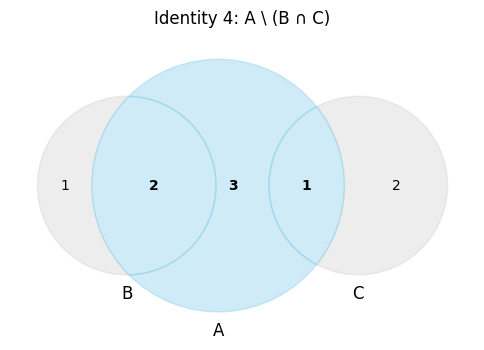

In [30]:
#4 𝐴∖(𝐵∩𝐶)=(𝐴∖𝐵)∪(𝐴∖𝐶)

highlight_venn3(A, B, C, "A", "B", "C", highlight_regions=['100', '101', '110'], title="Identity 4: A \\ (B ∩ C)")

# The shaded area represents A \ (B ∩ C), which is equal to (A \ B) ∪ (A \ C).

- 𝐴∖(𝐵∩𝐶) = (𝐴∖𝐵) ∪ (𝐴∖𝐶)

→ LHS: A 

→ RHS: {1,2,3,5} ∪ {1,2,3,4,6} = {1,2,3,4,5,6}

#### 1. b. Plot the following sets

1. $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$ 

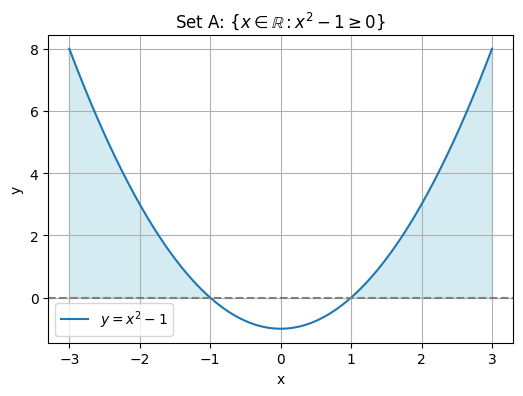

In [41]:
x = np.linspace(-3, 3, 400)
y = x**2 - 1
mask = (x <= -1) | (x >= 1)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r"$y = x^2 - 1$")
plt.fill_between(x, y, where=mask, color='lightblue', alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.title(r"Set A: $\{x \in \mathbb{R} : x^2 - 1 \geq 0\}$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

2. $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$

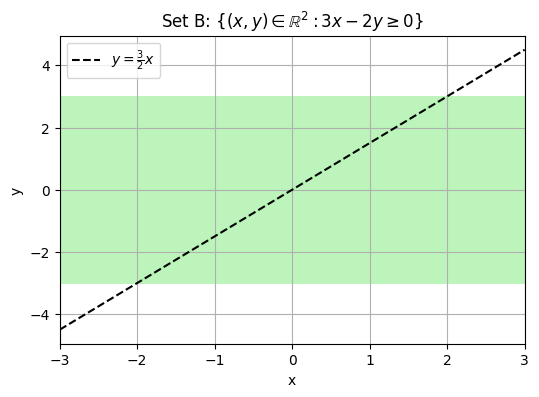

In [43]:
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
mask = 3 * X - 2 * Y >= 0

plt.figure(figsize=(6, 4))
plt.contourf(X, Y, mask, levels=1, colors=['lightgreen'], alpha=0.6)
plt.plot(x, (3/2)*x, 'k--', label=r"$y = \frac{3}{2}x$")
plt.title(r"Set B: $\{(x, y) \in \mathbb{R}^2 : 3x - 2y \geq 0\}$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

3. $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$

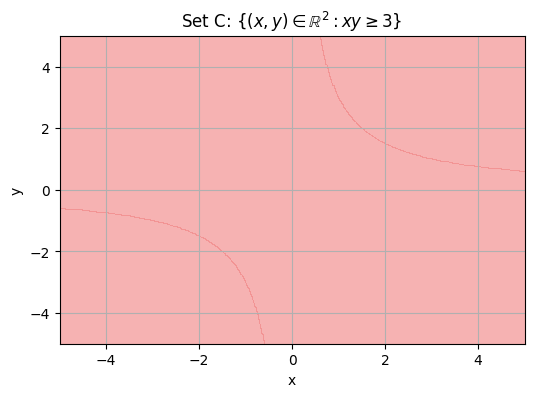

In [45]:
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
mask = X * Y >= 3

plt.figure(figsize=(6, 4))
plt.contourf(X, Y, mask, levels=1, colors=['lightcoral'], alpha=0.6)
plt.title(r"Set C: $\{(x, y) \in \mathbb{R}^2 : xy \geq 3\}$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


4. $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$

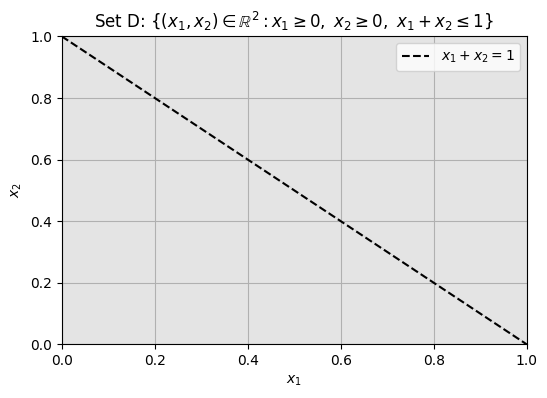

In [47]:
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x, y)
mask = (X >= 0) & (Y >= 0) & (X + Y <= 1)

plt.figure(figsize=(6, 4))
plt.contourf(X, Y, mask, levels=1, colors=['lightgray'], alpha=0.6)
plt.plot([0, 1], [1, 0], 'k--', label=r"$x_1 + x_2 = 1$")
plt.title(r"Set D: $\{(x_1, x_2) \in \mathbb{R}^2 : x_1 \geq 0,\ x_2 \geq 0,\ x_1 + x_2 \leq 1\}$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid(True)
plt.legend()
plt.show()


#### 1. c. Power Set

In [50]:
from itertools import product,chain, combinations

def power_set(s):
    """Returns the power set of the input set s."""
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))

# Example set
A = {1, 2, 3}
P_A = power_set(A)

# Display the power set
for subset in P_A:
    print(set(subset))


set()
{1}
{2}
{3}
{1, 2}
{1, 3}
{2, 3}
{1, 2, 3}


### 2. Probability space basics:

- What are the outcomes for rolling a single, fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?
- What about flipping a fair coin twice? (Hint: There are 4 outcomes, and $2^{4} = 16$ events.)
- What about rolling the **THREE**-sided die twice, and adding the results? Don't write down the set of all the possible events, but describe briefly what it looks like and how large it is. (Hint: There are 5 outcomes, and $2^{5}=32$ possible events.)

Obviously, a "three-sided die" doesn't exist, but this keeps you from spending a lot of time suffering in working out sets of events.

In [ ]:
# 1 : Rolling a Single, Fair Three-Sided Die

# Sample space
die = [1, 2, 3]

# Power set (all events)
def power_set(s):
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))

events = power_set(die)

# Probabilities
probabilities = {event: len(event) * (1/3) for event in events}

# Display
print("Sample space:", die)
print("Events and probabilities:")
for event in probabilities:
    print(f"{set(event)} → {probabilities[event]:.2f}")

Sample space: [1, 2, 3]
Events and probabilities:
set() → 0.00
{1} → 0.33
{2} → 0.33
{3} → 0.33
{1, 2} → 0.67
{1, 3} → 0.67
{2, 3} → 0.67
{1, 2, 3} → 1.00


In [ ]:
# 2 : Flipping a Fair Coin Twice

# Sample space
coin = ['H', 'T']
outcomes = list(product(coin, repeat=2))  # [('H','H'), ('H','T'), ('T','H'), ('T','T')]

# Power set (all events)
def power_set(s):
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))

events = power_set(outcomes)

# Probabilities
probabilities = {event: len(event) * (1/4) for event in events}

# Display
print("Sample space:", outcomes)
print("Events and probabilities:")
for event in probabilities:
    print(f"{event} → {probabilities[event]:.2f}")


Sample space: [('H', 'H'), ('H', 'T'), ('T', 'H'), ('T', 'T')]
Events and probabilities:
() → 0.00
(('H', 'H'),) → 0.25
(('H', 'T'),) → 0.25
(('T', 'H'),) → 0.25
(('T', 'T'),) → 0.25
(('H', 'H'), ('H', 'T')) → 0.50
(('H', 'H'), ('T', 'H')) → 0.50
(('H', 'H'), ('T', 'T')) → 0.50
(('H', 'T'), ('T', 'H')) → 0.50
(('H', 'T'), ('T', 'T')) → 0.50
(('T', 'H'), ('T', 'T')) → 0.50
(('H', 'H'), ('H', 'T'), ('T', 'H')) → 0.75
(('H', 'H'), ('H', 'T'), ('T', 'T')) → 0.75
(('H', 'H'), ('T', 'H'), ('T', 'T')) → 0.75
(('H', 'T'), ('T', 'H'), ('T', 'T')) → 0.75
(('H', 'H'), ('H', 'T'), ('T', 'H'), ('T', 'T')) → 1.00


In [53]:
# 3 : Rolling the Three-Sided Die Twice and Adding the Results 


# Sample space — all ordered pairs from two rolls
die = [1, 2, 3]
pairs = list(product(die, repeat=2))  # 9 outcomes like (1,1), (1,2), ...

# Compute all possible sums
sums = sorted(set(i + j for i, j in pairs))  # Unique sums: [2, 3, 4, 5, 6]

# Generate power set of sums (all possible events)
def power_set(s):
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s)+1)))

events = power_set(sums)

# Display summary
print("🎲 Rolling a 3-sided die twice and adding the results")
print("Sample space (sums):", sums)
print(f"Number of outcomes: {len(sums)}")
print(f"Number of possible events: {len(events)}\n")

print("Set of all possible events:")
for event in events:
    print(set(event))


🎲 Rolling a 3-sided die twice and adding the results
Sample space (sums): [2, 3, 4, 5, 6]
Number of outcomes: 5
Number of possible events: 32

Set of all possible events:
set()
{2}
{3}
{4}
{5}
{6}
{2, 3}
{2, 4}
{2, 5}
{2, 6}
{3, 4}
{3, 5}
{3, 6}
{4, 5}
{4, 6}
{5, 6}
{2, 3, 4}
{2, 3, 5}
{2, 3, 6}
{2, 4, 5}
{2, 4, 6}
{2, 5, 6}
{3, 4, 5}
{3, 4, 6}
{3, 5, 6}
{4, 5, 6}
{2, 3, 4, 5}
{2, 3, 4, 6}
{2, 3, 5, 6}
{2, 4, 5, 6}
{3, 4, 5, 6}
{2, 3, 4, 5, 6}


In [ ]:
# 3 : Rolling the Three-Sided Die Twice and Adding the Results (Probabilities)

# Sample space: all ordered pairs
die = [1, 2, 3]
pairs = list(product(die, repeat=2))

# Sum outcomes
sums = [i + j for i, j in pairs]

# Count frequencies
from collections import Counter
sum_counts = Counter(sums)

# Probabilities
total = len(pairs)
probabilities = {s: count / total for s, count in sum_counts.items()}

# Display
print("Sum outcomes and probabilities:")
for s in sorted(probabilities):
    print(f"Sum = {s} → Probability = {probabilities[s]:.2f}")

Sum outcomes and probabilities:
Sum = 2 → Probability = 0.11
Sum = 3 → Probability = 0.22
Sum = 4 → Probability = 0.33
Sum = 5 → Probability = 0.22
Sum = 6 → Probability = 0.11



### 3. Random Variable Basics

- Imagine rolling a fair single six-sided die. There are 6 outcomes, all equally likely. Derive the sample space and the space of events. What are the probabilities of the outcomes and events? 
- Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.
- Imagine rolling two fair six-sided die. Consider a random variable that adds up the pips on the dice. There are 11 outcomes (2 , 3, ..., 12), but not all are equally likely. Derive the sample space and **describe** the space of events. What are the probabilities of the outcomes?
- Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.

In [56]:
# Task 1: Sample space and probabilities for a fair six-sided die

sample_space = [1, 2, 3, 4, 5, 6]
probabilities = {outcome: 1/6 for outcome in sample_space}

print("Sample space:", sample_space)
print("Probabilities:", probabilities)


Sample space: [1, 2, 3, 4, 5, 6]
Probabilities: {1: 0.16666666666666666, 2: 0.16666666666666666, 3: 0.16666666666666666, 4: 0.16666666666666666, 5: 0.16666666666666666, 6: 0.16666666666666666}


In [57]:
# Task 2: Simulate 5000 rolls and compute sqrt(pips)

np.random.seed(42)
rolls = np.random.randint(1, 7, size=5000)
sqrt_values = np.sqrt(rolls)

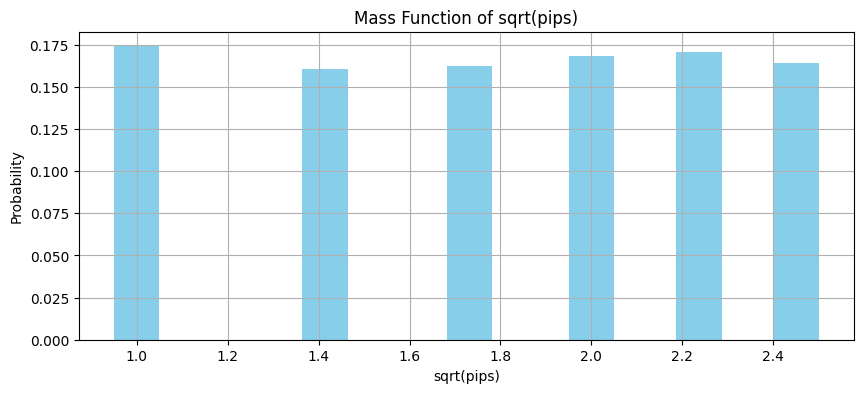

In [58]:
# Mass function
unique, counts = np.unique(sqrt_values, return_counts=True)
prob_mass = counts / len(sqrt_values)
plt.figure(figsize=(10, 4))
plt.bar(unique, prob_mass, width=0.1, color='skyblue')
plt.title('Mass Function of sqrt(pips)')
plt.xlabel('sqrt(pips)')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

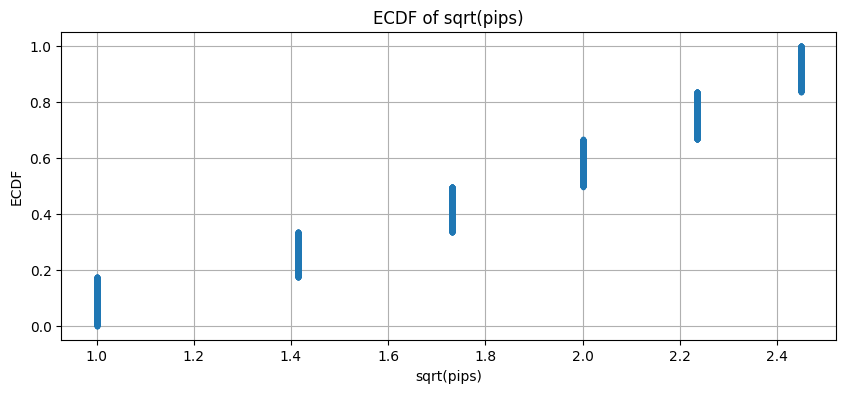

In [59]:

# ECDF
sorted_vals = np.sort(sqrt_values)
ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
plt.figure(figsize=(10, 4))
plt.plot(sorted_vals, ecdf, marker='.', linestyle='none')
plt.title('ECDF of sqrt(pips)')
plt.xlabel('sqrt(pips)')
plt.ylabel('ECDF')
plt.grid(True)
plt.show()


In [61]:
# Task 3: Sample space and probabilities for sum of two dice

sample_space_two_dice = [(i, j) for i in range(1, 7) for j in range(1, 7)]
sum_outcomes = [i + j for i, j in sample_space_two_dice]
counts = Counter(sum_outcomes)
total = len(sample_space_two_dice)
probabilities_two_dice = {k: v/total for k, v in sorted(counts.items())}
print("Probabilities of sums from two dice:", probabilities_two_dice)


Probabilities of sums from two dice: {2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666666, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}


In [63]:
# Task 4: Simulate 10000 rolls of two dice and plot mass function and ECDF

rolls_1 = np.random.randint(1, 7, size=10000)
rolls_2 = np.random.randint(1, 7, size=10000)
sums = rolls_1 + rolls_2


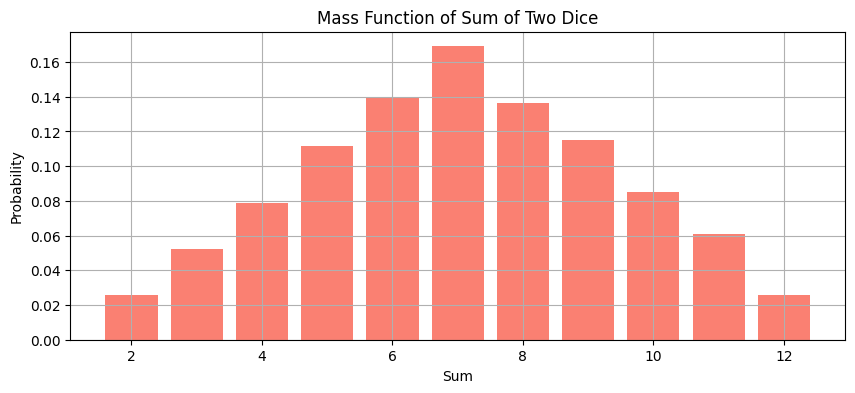

In [64]:
# Mass function
unique_sums, counts_sums = np.unique(sums, return_counts=True)
prob_mass_sums = counts_sums / len(sums)
plt.figure(figsize=(10, 4))
plt.bar(unique_sums, prob_mass_sums, color='salmon')
plt.title('Mass Function of Sum of Two Dice')
plt.xlabel('Sum')
plt.ylabel('Probability')
plt.grid(True)
plt.show()


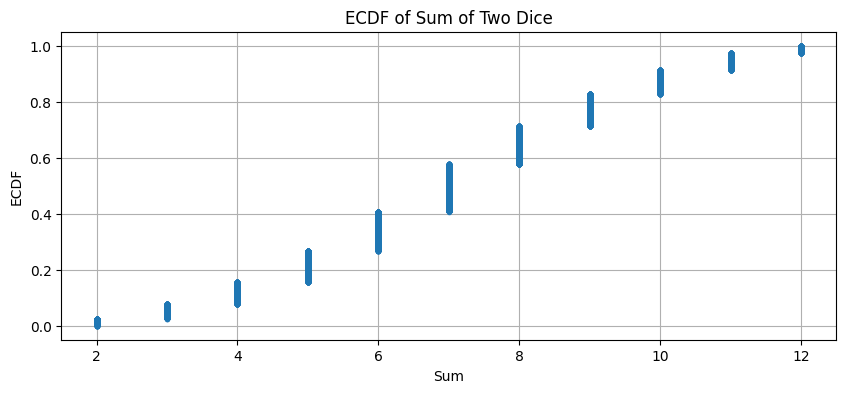

In [65]:
# ECDF
sorted_sums = np.sort(sums)
ecdf_sums = np.arange(1, len(sorted_sums)+1) / len(sorted_sums)
plt.figure(figsize=(10, 4))
plt.plot(sorted_sums, ecdf_sums, marker='.', linestyle='none')
plt.title('ECDF of Sum of Two Dice')
plt.xlabel('Sum')
plt.ylabel('ECDF')
plt.grid(True)
plt.show()

### 4. Roulette

This question will be easiest if you read the whole thing, and come up with a clear plan for how you'll write the code.

Roulette is a betting game. There are 37 possible outcomes: A green 0, and the numbers 1 to 36 in red and black. Here is a picture of the (American, not Euro, it has an extra green 00) betting board:

![Roulette](./src/euro_roulette.jpg)

To bet, you must pay a dollar, but then you get payouts that depend on how many slots are in your bet
- Basic bets:
    - Red or Black slots
    - Odd or Even slots
    - A single slots, like 20
- More complex bets:
    - Split: Two adjacent slots (e.g. {1,2})
    - Square: Four adjacent slots (e.g. {1,2,4,5})
    - Street: Three slots in a row (e.g. {1,2,3})
    - Line: Six slots (e.g. {1,2,3,4,5,6})
In general, you can only bet on 1, 2, 3, 4, 6 slots, 12 slots, or 18 slots. If your bet occurs when the wheel is spun, you gain 36/K-1 where $K$ is the number of slots you bet on; if not, you lose a dollar and get -1.

- Write code to model spinning the roulette wheel, including the colors and numbers (you could make two lists of number and color and draw a random number between 0 and 37... or use a dataframe with color and number variables and sample it... or use a dict with key to number/color pairs...)
- Describe the probability space associated with the roulette wheel: Outcomes, events, probabilities (If there are 37 outcomes, there are $2^{37}= 137,438,953,472$ events, by the way)
- You wrote code to generate a spin of the roulette wheel. Now write a function that takes a basic or complex bet as an argument, and returns the result for the player (win or lose, and the payout 36/K-1 or -1)
- Simulate betting on red, betting on odd, betting on 7, a split, and a line 1000 times each.
- Compute the average values for the bets you just simulated. What are the expected average payoffs?

#### Code to model spinning the roulette wheel

In [81]:
# Seed for reproducibility
np.random.seed(42)

# Step 1: Define numbers and colors
numbers = list(range(37))  # 0 to 36
colors = ['green'] + [
    'red' if i in range(1, 11) or i in range(19, 29) else 'black'
    for i in range(1, 37)
]

# Step 2: Create the roulette wheel as a DataFrame
wheel = pd.DataFrame({
    'number': numbers,
    'color': colors
})

# Step 3: Function to simulate a spin
def spin_wheel():
    result = wheel.sample(1).iloc[0]
    return {'number': result['number'], 'color': result['color']}

# Example usage
for _ in range(5):
    print("Spin result:", spin_wheel())

Spin result: {'number': np.int64(17), 'color': 'black'}
Spin result: {'number': np.int64(28), 'color': 'red'}
Spin result: {'number': np.int64(1), 'color': 'red'}
Spin result: {'number': np.int64(21), 'color': 'red'}
Spin result: {'number': np.int64(32), 'color': 'black'}


#### Probability Space

1. Sample Space (Ω)

- The roulette wheel has 37 distinct outcomes:

    - One green slot: 0

    - Eighteen red numbers: 1–10, 19–28

    - Eighteen black numbers: 11–18, 29–36

So the sample space is: Ω = {0,1,2,…,36}

Each outcome is equally likely, with: 𝑃(𝜔) = 1/37 for each 𝜔 ∈ Ω

2. Events

- An event is any subset of the sample space.

- Examples:

    - Betting on red: subset of 18 red numbers

    - Betting on odd: subset of 18 odd numbers

    - Betting on a split: subset of 2 adjacent numbers

- The total number of possible events is the size of the power set: ∣𝐹∣ = 2^37 = 137,438,953,472

That’s over 137 billion possible events!

3. Probability Measure

- For any event 𝐴 ⊆ Ω, the probability is:

𝑃(𝐴) = ∑𝜔∈𝐴 𝑃(𝜔) = ∣𝐴∣/ 37

Examples:

- Betting on red: 𝑃 (Red) = 18 / 37 ≈ 0.486

- Betting on a single number:  𝑃 ({7}) = 1/37 ≈ 0.027

- Betting on a line (6 numbers): 𝑃 (Line) = 6 / 37 ≈ 0.162

#### function to payout return

In [82]:
def evaluate_bet(spin_result, bet_slots):
    """
    Evaluates a roulette bet.
    
    Parameters:
    - spin_result: dict with keys 'number' and 'color'
    - bet_slots: list of numbers the player bet on
    
    Returns:
    - payout: float (36/K - 1 if win, else -1)
    """
    K = len(bet_slots)
    if spin_result['number'] in bet_slots:
        return 36 / K - 1
    else:
        return -1


In [83]:
# Simulate a spin
spin_result = {'number': 7, 'color': 'red'}

# Bet types
red_slots = wheel[wheel['color'] == 'red']['number'].tolist()
odd_slots = [i for i in range(1, 37) if i % 2 == 1]
split_slots = [7, 8]
line_slots = [1, 2, 3, 4, 5, 6]

# Evaluate each bet
print("Red bet:", evaluate_bet(spin_result, red_slots))
print("Odd bet:", evaluate_bet(spin_result, odd_slots))
print("Split bet:", evaluate_bet(spin_result, split_slots))
print("Line bet:", evaluate_bet(spin_result, line_slots))
print("Single bet:", evaluate_bet(spin_result, [7]))


Red bet: 0.8
Odd bet: 1.0
Split bet: 17.0
Line bet: -1
Single bet: 35.0


#### betting simulation

Average Payoffs:
Red: -0.037
Odd: -0.026
Single (7): -0.136
Split (7,8): 0.17
Line (1-6): -0.076


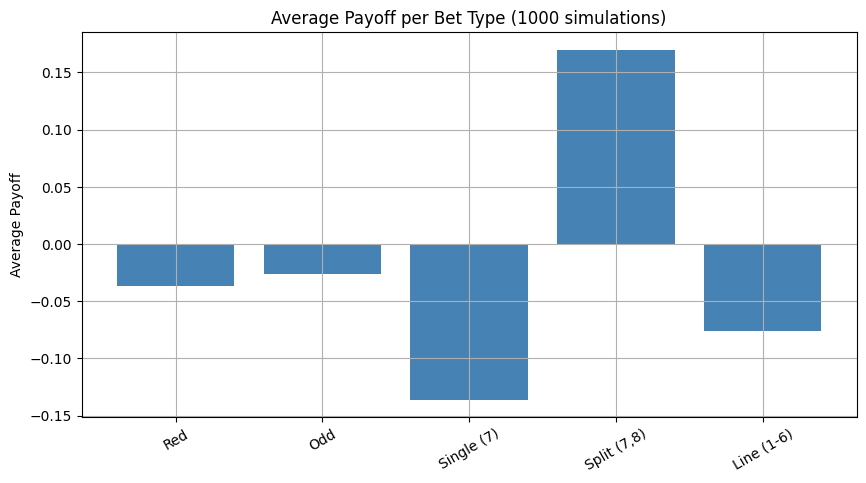

In [ ]:

# Seed for reproducibility
np.random.seed(42)

# Step 1: Define the roulette wheel
numbers = list(range(37))  # 0 to 36
colors = ['green'] + [
    'red' if i in range(1, 11) or i in range(19, 29) else 'black'
    for i in range(1, 37)
]
wheel = pd.DataFrame({'number': numbers, 'color': colors})

# Step 2: Spin function
def spin_wheel():
    return wheel.sample(1).iloc[0]

# Step 3: Bet evaluation function
def evaluate_bet(spin_result, bet_slots):
    K = len(bet_slots)
    return (36 / K - 1) if spin_result['number'] in bet_slots else -1

# Step 4: Define bet types
red_slots = wheel[wheel['color'] == 'red']['number'].tolist()
odd_slots = [i for i in range(1, 37) if i % 2 == 1]
single_slot = [7]
split_slots = [7, 8]
line_slots = [1, 2, 3, 4, 5, 6]

bets = {
    'Red': red_slots,
    'Odd': odd_slots,
    'Single (7)': single_slot,
    'Split (7,8)': split_slots,
    'Line (1-6)': line_slots
}

# Step 5: Simulate 1000 bets for each type
results = {}
for bet_name, bet_slots in bets.items():
    payouts = [evaluate_bet(spin_wheel(), bet_slots) for _ in range(1000)]
    results[bet_name] = payouts

# Step 6: Compute average payoffs
avg_payoffs = {bet: np.mean(payouts) for bet, payouts in results.items()}
print("Average Payoffs:")
for bet, avg in avg_payoffs.items():
    print(f"{bet}: {round(avg, 4)}")

# Step 7: Plot average payoffs
plt.figure(figsize=(10, 5))
plt.bar(avg_payoffs.keys(), avg_payoffs.values(), color='steelblue')
plt.title('Average Payoff per Bet Type (1000 simulations)')
plt.ylabel('Average Payoff')
plt.xticks(rotation=30)
plt.grid(True)
plt.show()


#### payoffs

In [86]:
# Compute and print average payoffs

print("Expected Average Payoffs (from 1000 simulations):")
for bet, payouts in results.items():
    avg = np.mean(payouts)
    print(f"{bet}: {round(avg, 4)}")

Expected Average Payoffs (from 1000 simulations):
Red: -0.037
Odd: -0.026
Single (7): -0.136
Split (7,8): 0.17
Line (1-6): -0.076


### 5. CDF and PDF Basics

- Verify the following functions are distribution functions and compute their density functions. Plot the distribution and density.

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1 
\end{cases}
$
2. $F(x) = \dfrac{1}{1+e^{-x}}$
3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$
4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$
5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

#### Solutions

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1 
\end{cases}
$

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_39171/2515098727.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.where(x <= 0, 0, np.where(x >= 1, 1, np.sqrt(x)))


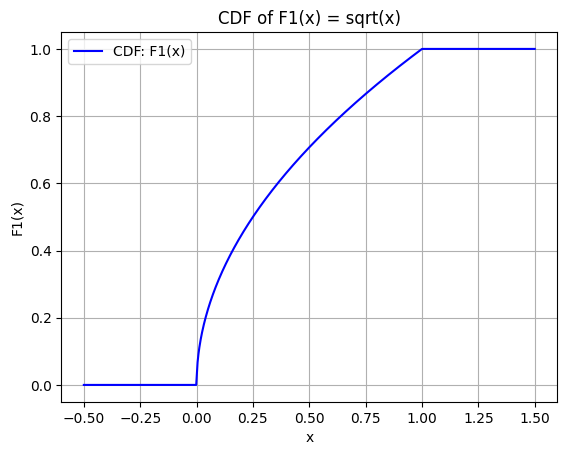

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_39171/2515098727.py:5: RuntimeWarning: invalid value encountered in sqrt
  return np.where((x > 0) & (x < 1), 0.5 / np.sqrt(x), 0)


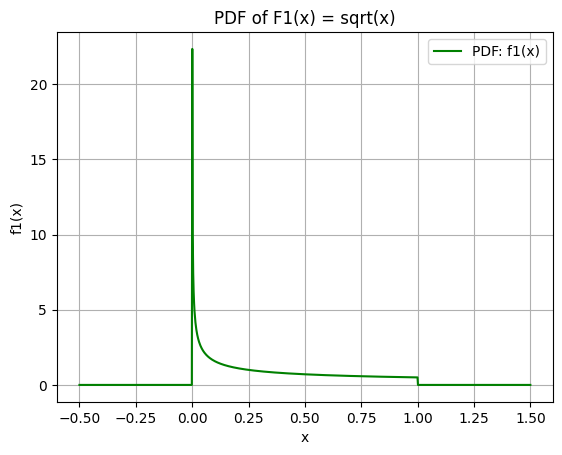

In [66]:
def F1(x):
    return np.where(x <= 0, 0, np.where(x >= 1, 1, np.sqrt(x)))

def f1(x):
    return np.where((x > 0) & (x < 1), 0.5 / np.sqrt(x), 0)

x_vals = np.linspace(-0.5, 1.5, 1000)

plt.plot(x_vals, F1(x_vals), label='CDF: F1(x)', color='blue')
plt.title('CDF of F1(x) = sqrt(x)')
plt.xlabel('x')
plt.ylabel('F1(x)')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x_vals, f1(x_vals), label='PDF: f1(x)', color='green')
plt.title('PDF of F1(x) = sqrt(x)')
plt.xlabel('x')
plt.ylabel('f1(x)')
plt.grid(True)
plt.legend()
plt.show()

2. $F(x) = \dfrac{1}{1+e^{-x}}$

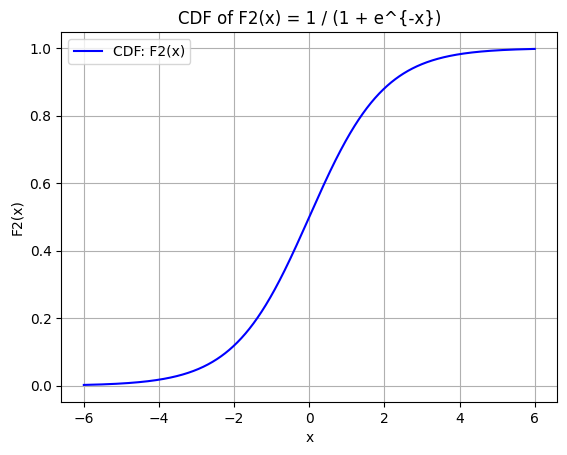

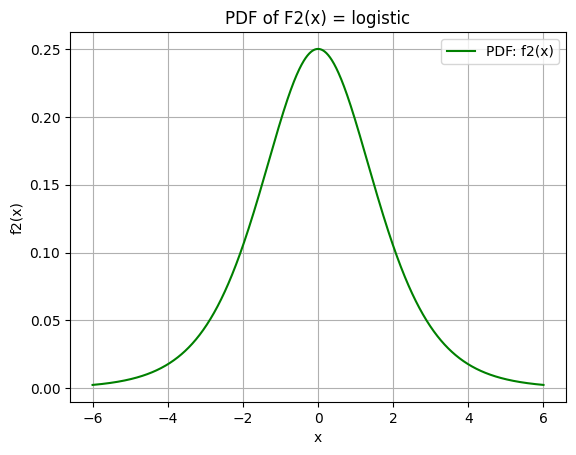

In [67]:
F2 = lambda x: 1 / (1 + np.exp(-x))
f2 = lambda x: np.exp(-x) / (1 + np.exp(-x))**2

x_vals = np.linspace(-6, 6, 1000)

plt.plot(x_vals, F2(x_vals), label='CDF: F2(x)', color='blue')
plt.title('CDF of F2(x) = 1 / (1 + e^{-x})')
plt.xlabel('x')
plt.ylabel('F2(x)')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x_vals, f2(x_vals), label='PDF: f2(x)', color='green')
plt.title('PDF of F2(x) = logistic')
plt.xlabel('x')
plt.ylabel('f2(x)')
plt.grid(True)
plt.legend()
plt.show()


3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$

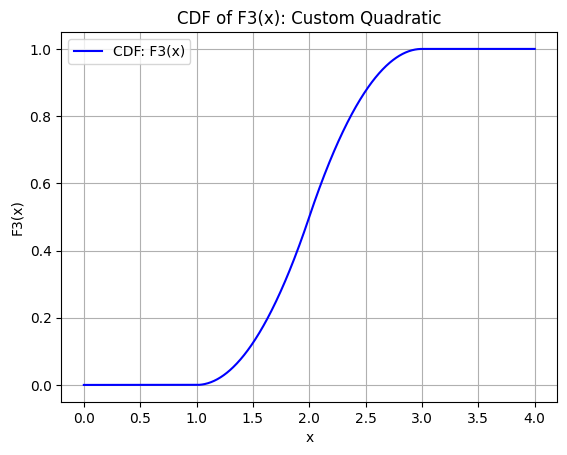

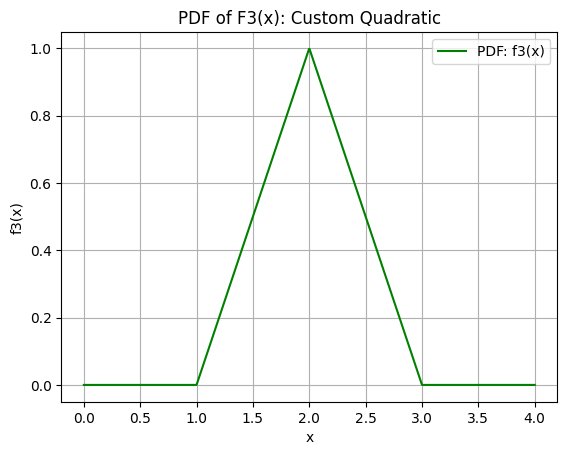

In [68]:
a, b, c = 1, 3, 2

def F3(x):
    return np.where(x <= 0, 0,
                    np.where((x >= a) & (x <= c), ((x-a)**2)/((b-a)*(b-c)),
                             np.where((x > c) & (x < b), 1 - ((b-x)**2)/((b-a)*(b-c)),
                                      np.where(x >= b, 1, 0))))

def f3(x):
    return np.where((x >= a) & (x <= c), 2*(x-a)/((b-a)*(b-c)),
                    np.where((x > c) & (x < b), 2*(b-x)/((b-a)*(b-c)), 0))

x_vals = np.linspace(0, 4, 1000)

plt.plot(x_vals, F3(x_vals), label='CDF: F3(x)', color='blue')
plt.title('CDF of F3(x): Custom Quadratic')
plt.xlabel('x')
plt.ylabel('F3(x)')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x_vals, f3(x_vals), label='PDF: f3(x)', color='green')
plt.title('PDF of F3(x): Custom Quadratic')
plt.xlabel('x')
plt.ylabel('f3(x)')
plt.grid(True)
plt.legend()
plt.show()


4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$

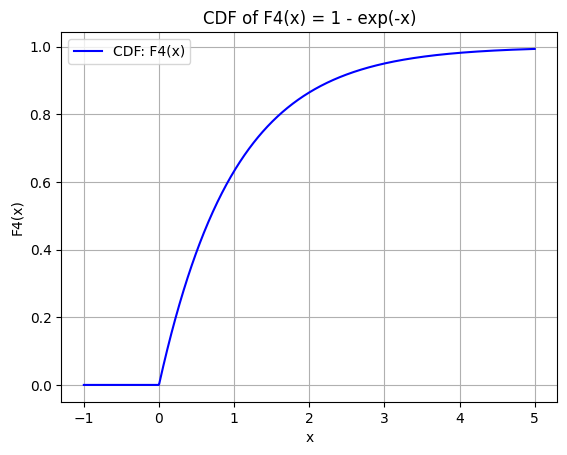

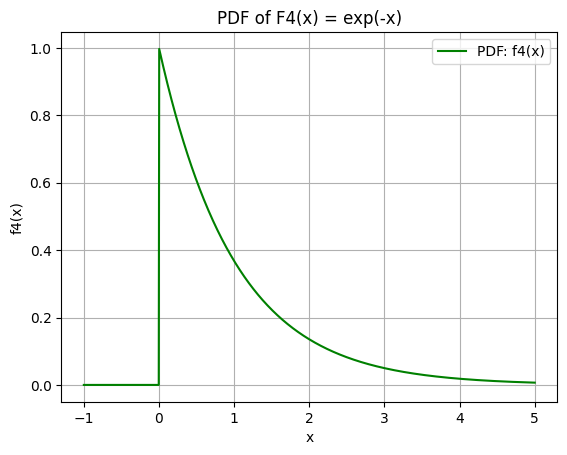

In [69]:
F4 = lambda x: np.where(x < 0, 0, 1 - np.exp(-x))
f4 = lambda x: np.where(x < 0, 0, np.exp(-x))

x_vals = np.linspace(-1, 5, 1000)

plt.plot(x_vals, F4(x_vals), label='CDF: F4(x)', color='blue')
plt.title('CDF of F4(x) = 1 - exp(-x)')
plt.xlabel('x')
plt.ylabel('F4(x)')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x_vals, f4(x_vals), label='PDF: f4(x)', color='green')
plt.title('PDF of F4(x) = exp(-x)')
plt.xlabel('x')
plt.ylabel('f4(x)')
plt.grid(True)
plt.legend()
plt.show()


5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

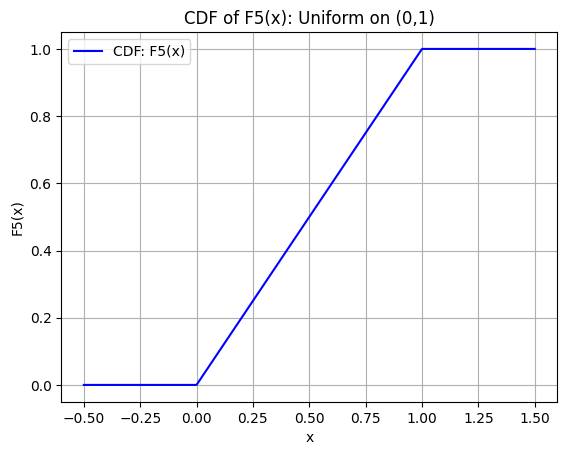

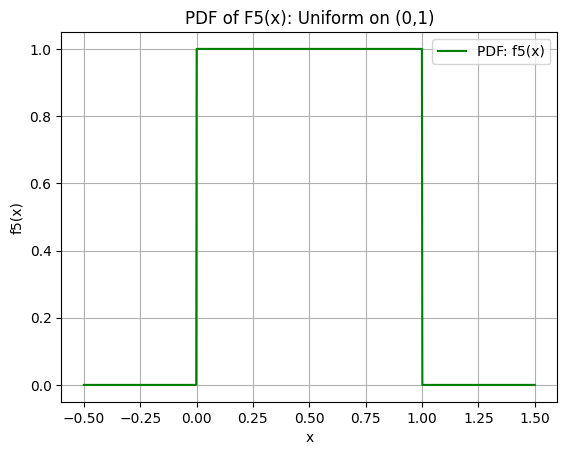

In [70]:
F5 = lambda x: np.where(x <= 0, 0, np.where(x >= 1, 1, x))
f5 = lambda x: np.where((x > 0) & (x < 1), 1, 0)

x_vals = np.linspace(-0.5, 1.5, 1000)

plt.plot(x_vals, F5(x_vals), label='CDF: F5(x)', color='blue')
plt.title('CDF of F5(x): Uniform on (0,1)')
plt.xlabel('x')
plt.ylabel('F5(x)')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x_vals, f5(x_vals), label='PDF: f5(x)', color='green')
plt.title('PDF of F5(x): Uniform on (0,1)')
plt.xlabel('x')
plt.ylabel('f5(x)')
plt.grid(True)
plt.legend()
plt.show()


### 6. Some Common Distributions

For the following distributions:
- Determine the support
- Compute the density from the distribution for the logistic and exponential distributions (take a derivative)
- Plot the density and distribution for a variety of parameter values
- Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf
- Find an example of this general type of PDF/CDF from the Metabric cancer data

You can use https://docs.scipy.org/doc/scipy/reference/stats.html to generate values for the pdf/cdf and generate samples of random variates.


- Logistic distribution (similar to normal): 
$$
F(x; \sigma) = \dfrac{1}{1+e^{-x/\sigma}} 
$$
with $\sigma >0$.
- Exponential distribution (similar to log-normal):
$$
F_X(x) = \begin{cases}
0, & x<0 \\
1 - e^{-\lambda x}, & x \ge 0,
\end{cases}
$$
with $\lambda > 0$.
- Negative Binomial (similar to Poisson): The probability mass function for positive integers is:
$$
f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r, \quad \text{ for $k=0,...n$}
$$
You can interpret this as follows: Flip a coin that comes up heads with probability $p$ until you get $r$ heads, and then stop. What is the probability of stopping at each $k=0,1,2,...$?
- Categorical (similar to Bernoulli): The probability mass function over $k = 1, 2, ..., K$ categories is
$$
f(k;p_1,...,p_K) = p_1^{k=1}p_2^{k=2}...p_K^{k=K}
$$
where $0 \le p_i \le 1$ and $ \sum_{k=1}^K p_k = 1$.


##### Determine the support

In [88]:
# Define support ranges
x_log = np.linspace(-10, 10, 1000)     # Logistic: (-∞, ∞)
x_exp = np.linspace(0, 10, 1000)       # Exponential: [0, ∞)

Logistic distribution: support is (−∞,∞)

Exponential distribution: support is [0,∞)

##### Compute the density from the distribution for the logistic and exponential distributions (take a derivative)

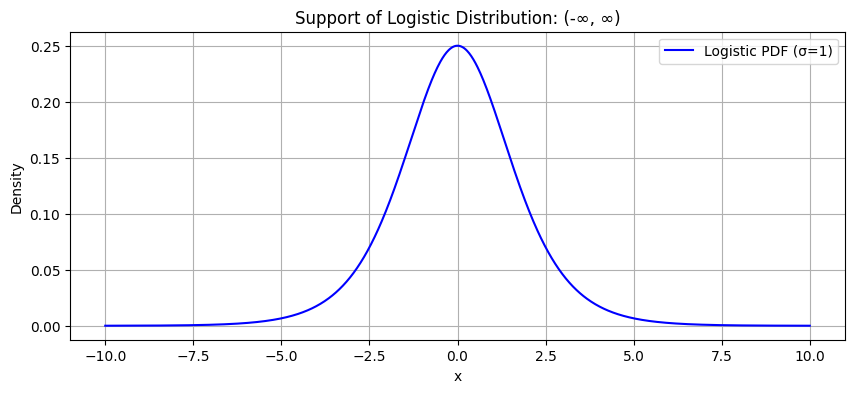

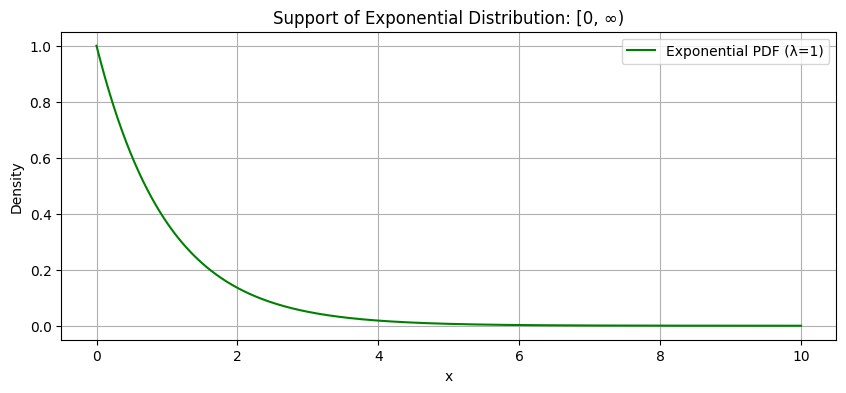

In [89]:
# Plot logistic support
plt.figure(figsize=(10, 4))
plt.plot(x_log, logistic.pdf(x_log, scale=1), label='Logistic PDF (σ=1)', color='blue')
plt.title('Support of Logistic Distribution: (-∞, ∞)')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

# Plot exponential support
plt.figure(figsize=(10, 4))
plt.plot(x_exp, expon.pdf(x_exp, scale=1), label='Exponential PDF (λ=1)', color='green')
plt.title('Support of Exponential Distribution: [0, ∞)')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

##### Plot the density and distribution for a variety of parameter values


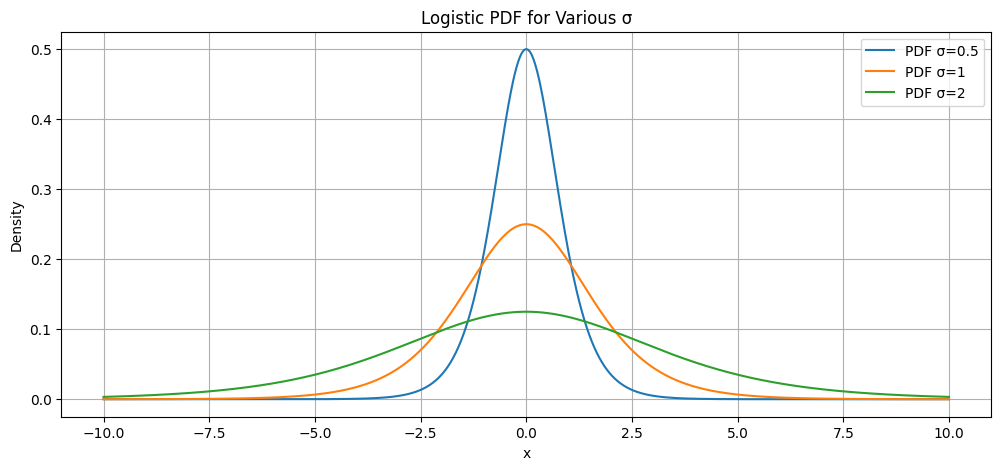

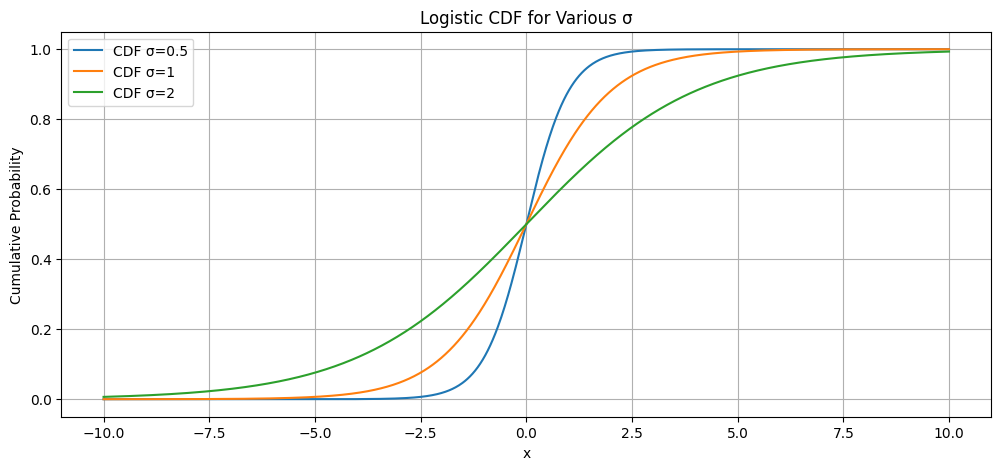

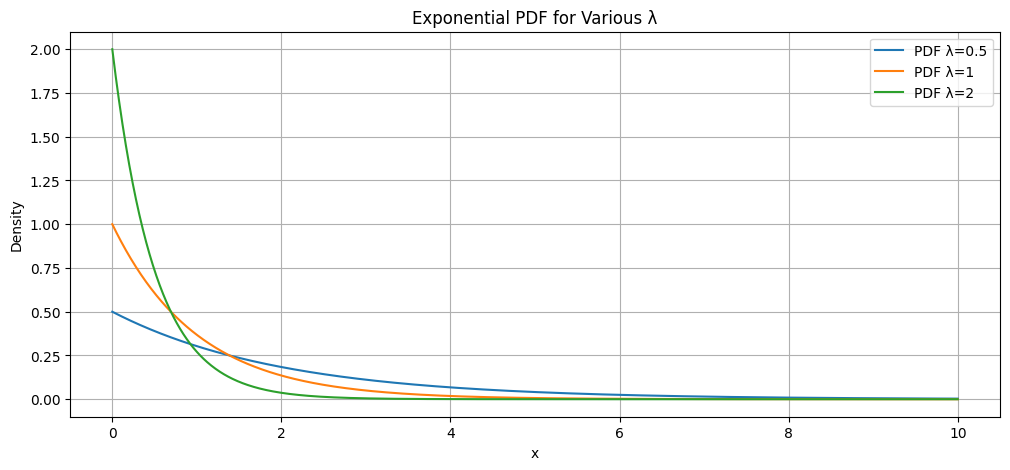

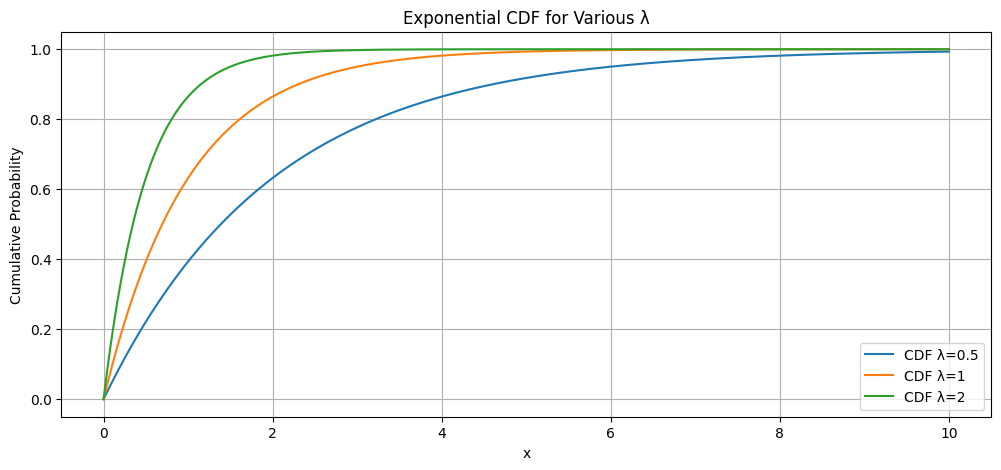

In [90]:
np.random.seed(42)

# Logistic parameters (σ)
sigmas = [0.5, 1, 2]

plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(x_log, logistic.pdf(x_log, scale=sigma), label=f'PDF σ={sigma}')
plt.title('Logistic PDF for Various σ')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(x_log, logistic.cdf(x_log, scale=sigma), label=f'CDF σ={sigma}')
plt.title('Logistic CDF for Various σ')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.show()

# Exponential parameters (λ)
lambdas = [0.5, 1, 2]

plt.figure(figsize=(12, 5))
for lam in lambdas:
    plt.plot(x_exp, expon.pdf(x_exp, scale=1/lam), label=f'PDF λ={lam}')
plt.title('Exponential PDF for Various λ')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
for lam in lambdas:
    plt.plot(x_exp, expon.cdf(x_exp, scale=1/lam), label=f'CDF λ={lam}')
plt.title('Exponential CDF for Various λ')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.show()


##### Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf


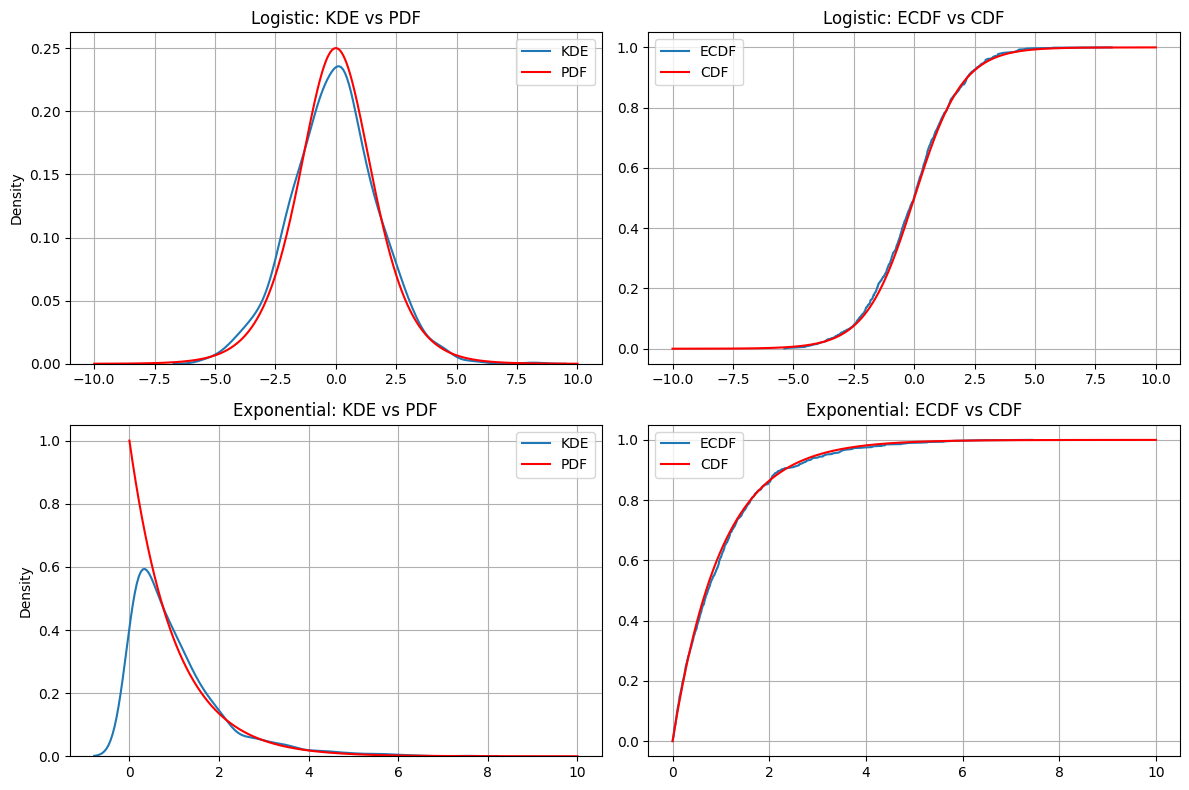

In [93]:
np.random.seed(42)

# Step 1: Sample 1000 draws
samples_log = logistic.rvs(size=1000, scale=1)
samples_exp = expon.rvs(size=1000, scale=1)

# Step 2: Define x ranges
x_log = np.linspace(-10, 10, 1000)
x_exp = np.linspace(0, 10, 1000)

# Step 3: Plot KDE vs PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Logistic KDE vs PDF
sns.kdeplot(samples_log, ax=axs[0, 0], label='KDE')
axs[0, 0].plot(x_log, logistic.pdf(x_log, scale=1), label='PDF', color='red')
axs[0, 0].set_title('Logistic: KDE vs PDF')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Exponential KDE vs PDF
sns.kdeplot(samples_exp, ax=axs[1, 0], label='KDE')
axs[1, 0].plot(x_exp, expon.pdf(x_exp, scale=1), label='PDF', color='red')
axs[1, 0].set_title('Exponential: KDE vs PDF')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Logistic ECDF vs CDF
axs[0, 1].plot(np.sort(samples_log), np.arange(1, 1001)/1000, label='ECDF')
axs[0, 1].plot(x_log, logistic.cdf(x_log, scale=1), label='CDF', color='red')
axs[0, 1].set_title('Logistic: ECDF vs CDF')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Exponential ECDF vs CDF
axs[1, 1].plot(np.sort(samples_exp), np.arange(1, 1001)/1000, label='ECDF')
axs[1, 1].plot(x_exp, expon.cdf(x_exp, scale=1), label='CDF', color='red')
axs[1, 1].set_title('Exponential: ECDF vs CDF')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


##### Find an example of this general type of PDF/CDF from the Metabric cancer data

In [5]:
# Load Metabric data (replace with actual path if needed)
df = pd.read_csv("metabric.csv")

df.head()
print(df.columns)

Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
       'Chemotherapy', 'Hormone Therapy', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index',
       'Overall Survival (Months)', 'Overall Survival Status', 'Radio Therapy',
       'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage'],
      dtype='object')


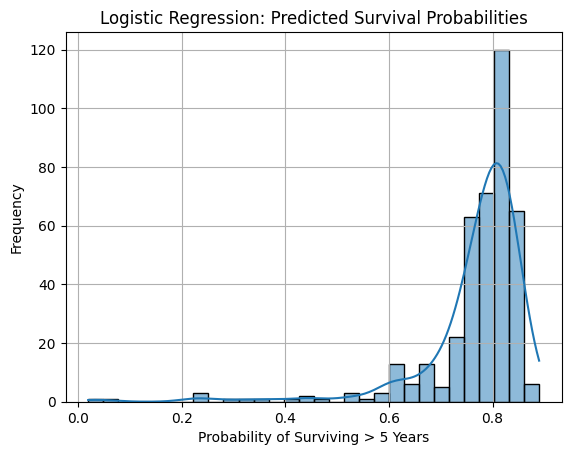

In [6]:
# Binary target: 5-year survival
df["Overall Survival Status"] = (df["Overall Survival (Months)"] > 60).astype(int)

# Feature: tumor size (or any numeric column)
X = df[["Tumor Size"]].fillna(0)
y = df["Overall Survival Status"]

# Train logistic regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities
probs = model.predict_proba(X_test)[:, 1]

# Plot logistic CDF-like curve
sns.histplot(probs, bins=30, kde=True)
plt.title("Logistic Regression: Predicted Survival Probabilities")
plt.xlabel("Probability of Surviving > 5 Years")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


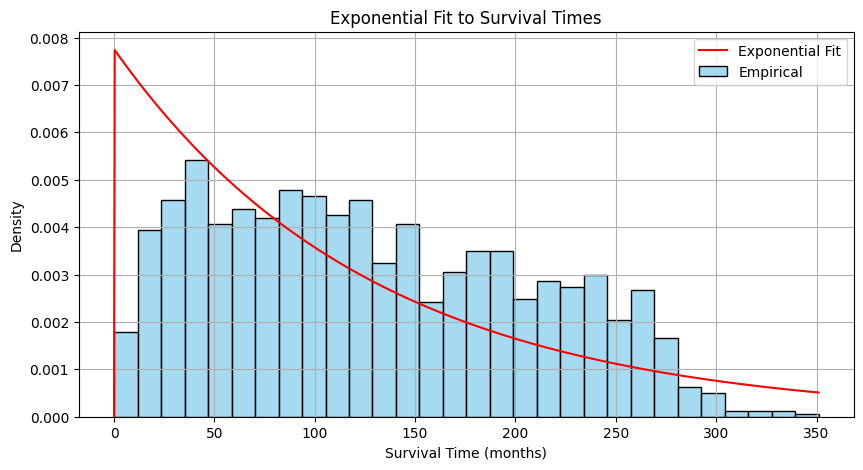

In [7]:

# Fit exponential to survival times
survival_times = df["Overall Survival (Months)"].dropna()
params = expon.fit(survival_times)

# Plot histogram and fitted PDF
x = np.linspace(0, survival_times.max(), 1000)
pdf = expon.pdf(x, *params)

plt.figure(figsize=(10, 5))
sns.histplot(survival_times, bins=30, stat='density', label='Empirical', color='skyblue')
plt.plot(x, pdf, label='Exponential Fit', color='red')
plt.title("Exponential Fit to Survival Times")
plt.xlabel("Survival Time (months)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()
